# Predições — Feed-Forward Neural Network (FFNN)

Este notebook carrega o modelo exportado (`best_ffnn.pt`) e gera um CSV de predições com colunas `ID` e `Label`.

**Pré-requisitos:**
- Ter corrido a secção correspondente do notebook de treino (`../models_pytorch.ipynb`) → pasta `exported_models/` com o `.pt`
- CSV de inferência com coluna `Text` (e opcionalmente `ID`; se não existir usa o índice de linha)

## 1. Configuração

In [1]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Caminhos ──────────────────────────────────────────────────────────────────
FFNN_MODEL_PATH  = "../exported_models/best_ffnn.pt"
SUBM3_CSV        = "../data/subm3.csv"
CSV_SEP          = ";"
TEXT_COL         = "Text"
ID_COL           = "ID"
OUTPUT_FFNN      = "subm3-g9-MEI-A.csv"
BATCH_SIZE       = 256

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cpu


## 2. Pré-processamento (One-hot)

In [2]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def vectorize_text(text, word_index, max_words):
    """One-hot: presença/ausência de cada palavra."""
    vector = torch.zeros(max_words)
    for word in set(text.split()):
        if word in word_index:
            vector[word_index[word]] = 1
    return vector

## 3. Definição da Arquitetura

In [3]:
class FFNN(nn.Module):
    def __init__(self, input_dim, topology=[256, 128], dropout=0.3, num_classes=5):
        super().__init__()
        layers = []
        prev = input_dim
        for h in topology:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Dataset de Inferência

In [4]:
class OneHotInferenceDataset(Dataset):
    def __init__(self, texts, word_index, max_words):
        self.texts      = texts
        self.word_index = word_index
        self.max_words  = max_words

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        return vectorize_text(self.texts[idx], self.word_index, self.max_words)

## 5. Funções de Carregamento e Inferência

In [5]:
def load_ffnn(path, device):
    """Reconstrói o FFNN a partir do checkpoint."""
    ckpt  = torch.load(path, map_location=device)
    cfg   = ckpt["config"]
    model = FFNN(
        input_dim   = cfg["input_dim"],
        topology    = cfg["topology"],
        dropout     = cfg["dropout"],
        num_classes = cfg["num_classes"],
    )
    model.load_state_dict(ckpt["model_state"])
    model.to(device).eval()
    return model, ckpt

@torch.no_grad()
def predict(model, loader, idx2label, device):
    """Corre inferência e devolve lista de strings com as labels previstas."""
    preds = []
    for batch in loader:
        logits = model(batch.to(device))
        preds.extend(logits.argmax(1).cpu().tolist())
    return [idx2label[i] for i in preds]

def save_predictions(ids, labels, output_path):
    """Guarda CSV com colunas ID e Label."""
    df = pd.DataFrame({"ID": ids, "Label": labels})
    df.to_csv(output_path, index=False, sep=";")
    print(f"  ✅ {len(df)} predições guardadas em: {output_path}")
    from IPython.display import display
    display(df.head(10))
    return df

## 6. Carregar CSV de Inferência

In [6]:
df_infer = pd.read_csv(SUBM3_CSV, sep=CSV_SEP)
print(f"Linhas: {len(df_infer)}   Colunas: {list(df_infer.columns)}")

# IDs: usa coluna ID_COL se existir, senão índice de linha
if ID_COL and ID_COL in df_infer.columns:
    ids = df_infer[ID_COL].tolist()
else:
    print(f"  ⚠️  Coluna '{ID_COL}' não encontrada — a usar índice de linha como ID.")
    ids = list(range(len(df_infer)))

texts = [clean_text(t) for t in df_infer[TEXT_COL].tolist()]
print(f"Exemplo limpo: {texts[0][:80]}...")

Linhas: 150   Colunas: ['ID', 'Text']
Exemplo limpo: the reality about the places that diamonds are found is that our planet might ho...


## 7. Predições

In [7]:
print("▶ Carregando FFNN...")
ffnn_model, ffnn_ckpt = load_ffnn(FFNN_MODEL_PATH, DEVICE)
print(f"   Arquitectura : FFNN {ffnn_ckpt['config']['topology']}")
print(f"   Representação: {ffnn_ckpt['representation']}")

ffnn_dataset = OneHotInferenceDataset(
    texts,
    word_index = ffnn_ckpt["word_index"],
    max_words  = ffnn_ckpt["max_words"],
)
ffnn_loader = DataLoader(ffnn_dataset, batch_size=BATCH_SIZE)

ffnn_preds = predict(ffnn_model, ffnn_loader, ffnn_ckpt["idx2label"], DEVICE)
df_ffnn    = save_predictions(ids, ffnn_preds, OUTPUT_FFNN)

▶ Carregando FFNN...
   Arquitectura : FFNN [512, 256, 128]
   Representação: one_hot
  ✅ 150 predições guardadas em: subm3-g9-MEI-A.csv


,ID,Label
0,D2-126,Human
1,D2-127,Human
2,D2-128,OpenAI
3,D2-129,OpenAI
4,D2-130,Meta
5,D2-131,Meta
6,D2-132,OpenAI
7,D2-133,Google
8,D2-134,OpenAI
9,D2-135,Google


## 8. Distribuição das Predições

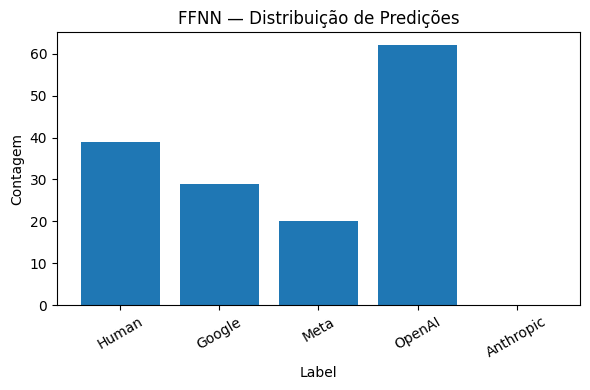

In [8]:
import matplotlib.pyplot as plt

counts = df_ffnn["Label"].value_counts().reindex(ffnn_ckpt["labels"], fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("FFNN — Distribuição de Predições")
plt.xlabel("Label")
plt.ylabel("Contagem")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()